In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler, normalize
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
bank=pd.read_excel("/content/drive/MyDrive/Imarticus/PGA44/Decision_tree/bank.xlsx", sheet_name="bank")

In [4]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
bank.select_dtypes("object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

In [6]:
bank["job"].value_counts()

,count
job,
management,2566
blue-collar,1944
technician,1823
admin.,1334
services,923
retired,778
self-employed,405
student,360
unemployed,357


In [7]:
bank["job"]=bank["job"].replace(["unemployed", "student", "retired"], "Not_earning")
bank["job"]=bank["job"].replace(["housemaid", "services", "admin."], "pink_collar")
bank["job"]=bank["job"].replace(["self-employed", "entrepreneur"], "Self_earning")

In [8]:
bank["job"].value_counts()

,count
job,
management,2566
pink_collar,2531
blue-collar,1944
technician,1823
Not_earning,1495
Self_earning,733
unknown,70


In [9]:
bank["marital"].value_counts()

,count
marital,
married,6351
single,3518
divorced,1293


In [10]:
bank["education"].value_counts()

,count
education,
secondary,5476
tertiary,3689
primary,1500
unknown,497


In [11]:
bank["default"].value_counts()

,count
default,
no,10994
yes,168


In [12]:
bank["loan"].value_counts()

,count
loan,
no,9702
yes,1460


In [13]:
bank["housing"].value_counts()

,count
housing,
no,5881
yes,5281


In [14]:
bank["contact"].value_counts()

,count
contact,
cellular,8042
unknown,2346
telephone,774


In [15]:
bank["month"].value_counts()

,count
month,
may,2824
aug,1519
jul,1514
jun,1222
nov,943
apr,923
feb,776
oct,392
jan,344


In [16]:
bank["deposit"].value_counts()

,count
deposit,
no,5873
yes,5289


In [17]:
bank["deposit"]=bank["deposit"].map({"yes":1, "no":0})

In [18]:
# Outlier capping
def Outliers(x):
  x=x.clip(upper=x.quantile(.99))
  x=x.clip(lower=x.quantile(.01))
  return x

In [19]:
num=bank.select_dtypes("int").apply(Outliers)  # outlier treatment done

In [20]:
# num
ob=bank.select_dtypes("object")

In [21]:
bank_data=pd.concat([num, ob], axis=1)

In [22]:
final_data=pd.get_dummies(bank_data,
                          columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','poutcome', "month"],
                          drop_first=True)

In [23]:
final_data.shape

(11162, 38)

In [24]:
# Model
y=final_data["deposit"]
x=final_data.drop(columns=["deposit"])
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.3, random_state=0)

In [25]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression( max_iter=10000)
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

In [26]:
lr.score(x_train, y_train)

0.8292589274286446

In [27]:
lr.score(x_test, y_test)

0.8232308151687071

In [28]:
dt=DecisionTreeClassifier()

In [29]:
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [30]:
dt.score(x_train, y_train)

1.0

In [31]:
dt.score(x_test, y_test)

0.7924753657808301

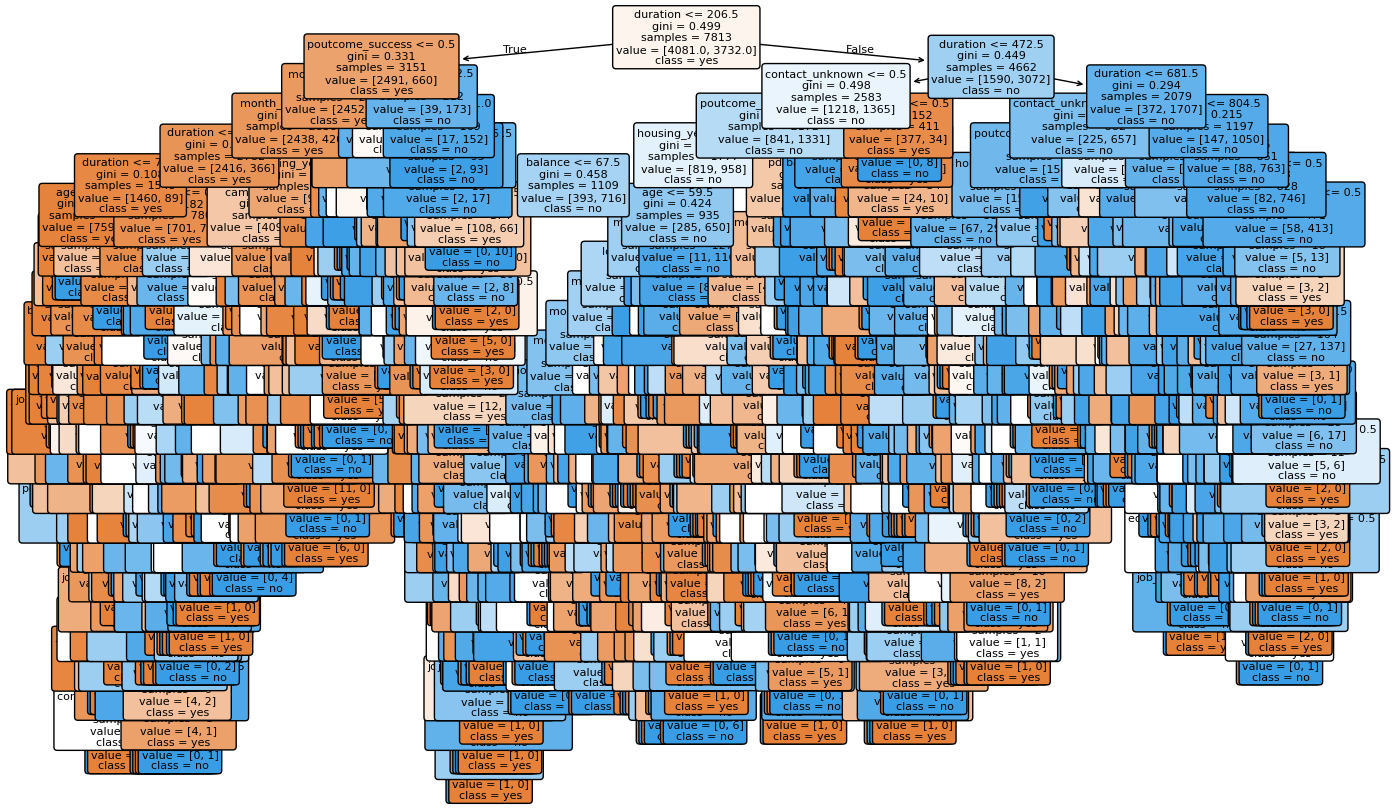

In [32]:
# Plot with larger nodes
plt.figure(figsize=(16, 10))  # Increase figure size
plot_tree(dt,
          feature_names=x.columns,
          class_names=["yes", "no"] ,
          filled=True,
          rounded=True,
          fontsize=8)  # Increase font size
plt.show()

In [33]:

dt_model=DecisionTreeClassifier(criterion="gini", max_depth=10, min_samples_split=300)  # creating object of Decision Tree model
dt_model.fit(x_train, y_train)
print("train Score/Accuracy :", dt_model.score(x_train, y_train))
print("test Score/Accuracy : ", dt_model.score(x_test, y_test))


train Score/Accuracy : 0.83002687827979
test Score/Accuracy :  0.8208420424007167


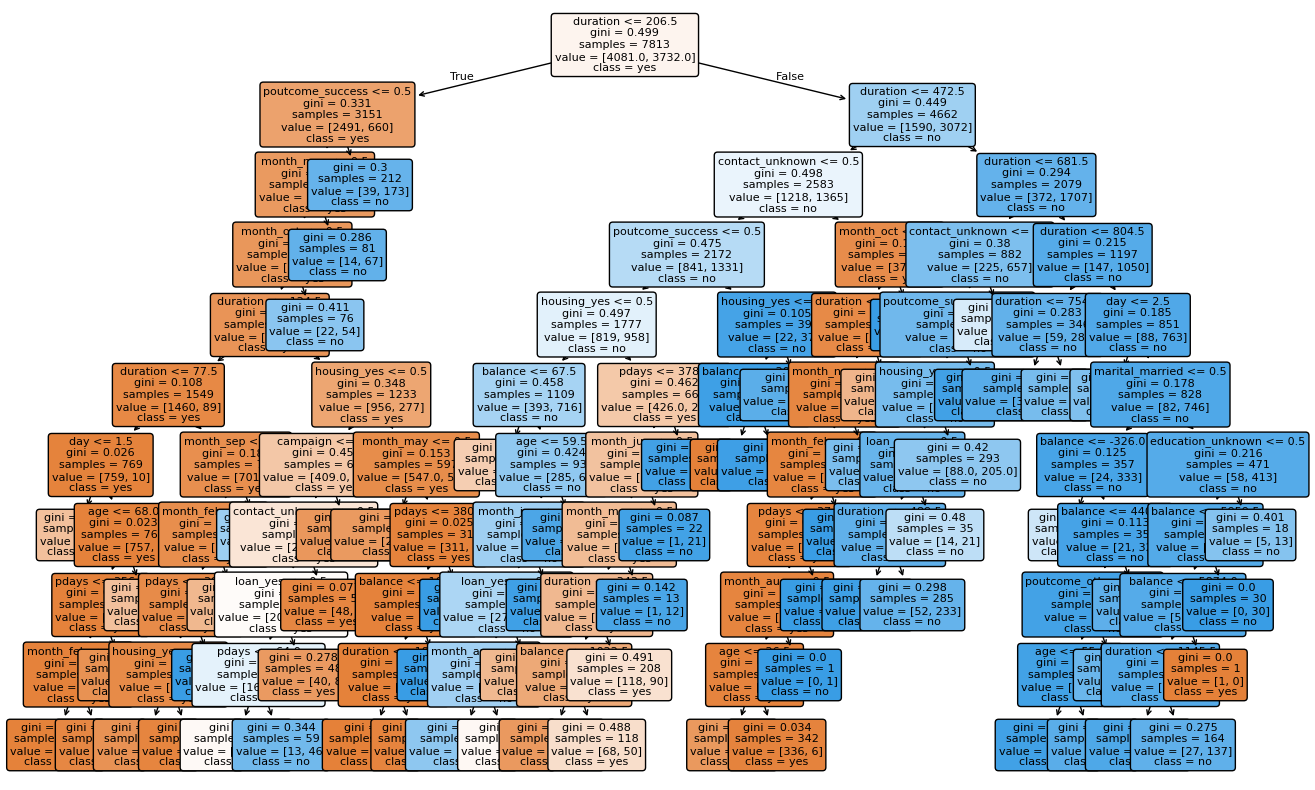

In [34]:
# Plot with larger nodes
plt.figure(figsize=(16, 10))  # Increase figure size
plot_tree(dt_model,
          feature_names=x.columns,
          class_names=["yes", "no"] ,
          filled=True,
          rounded=True,
          fontsize=8)  # Increase font size
plt.show()

In [36]:
2*6*6*7*10

5040

In [37]:
# Hyperparameter tuning
import time
tic=time.time()
from sklearn.model_selection import GridSearchCV

params={"criterion" : ["gini", "entropy"],
        "max_depth":[5,7 ,8,10,12,14],
        "min_samples_split":[50,100, 120, 150, 200, 250],
        "min_samples_leaf":[5,10,15,20,30,40,50]}

dt=DecisionTreeClassifier(random_state=0)

grid=GridSearchCV(estimator=dt, param_grid=params, cv=10, scoring="accuracy", verbose=3, n_jobs=-1)
grid.fit(x_train, y_train)
toc=time.time()
print("Time taken : ", toc-tic)

Fitting 10 folds for each of 504 candidates, totalling 5040 fits
Time taken :  186.37798357009888


In [38]:
grid.best_params_  # Best parameters

{'criterion': 'entropy',
 'max_depth': 14,
 'min_samples_leaf': 15,
 'min_samples_split': 100}

In [39]:
grid.best_params_["criterion"]

'entropy'

In [40]:
grid.best_score_

np.float64(0.8362999433476002)

In [41]:
dt3=DecisionTreeClassifier(criterion="entropy",
                           max_depth=14,
                           min_samples_split=100,
                           min_samples_leaf=15)

In [42]:
dt3.fit(x_train, y_train)
print("train Accuracy", dt3.score(x_train, y_train))
print("test Accuracy", dt3.score(x_test, y_test))

train Accuracy 0.8531933956226802
test Accuracy 0.8289041504926844


In [45]:
pd.DataFrame({"Columns":x_train.columns, "Imp":dt3.feature_importances_}).sort_values(by=["Imp"], ascending=False)

,Columns,Imp
3,duration,0.442420
24,poutcome_success,0.121957
22,contact_unknown,0.118765
19,housing_yes,0.046071
31,month_jun,0.030092
1,balance,0.029542
2,day,0.027801
0,age,0.021746
26,month_aug,0.020707
5,pdays,0.020026


In [47]:
# Feature importance
d=pd.DataFrame({"features":x_train.columns, "imp":dt3.feature_importances_}).sort_values(by=["imp"], ascending=False)
selected_feat=d[d["imp"]>=.01]["features"].values
selected_feat


array(['duration', 'poutcome_success', 'contact_unknown', 'housing_yes',
       'month_jun', 'balance', 'day', 'age', 'month_aug', 'pdays',
       'month_mar', 'month_jul', 'month_may', 'month_nov'], dtype=object)

In [48]:
y=final_data["deposit"]
x=final_data[selected_feat]

In [49]:
x_train1,x_test1,y_train1, y_test1=train_test_split(x,y,test_size=.3, random_state=0)

In [50]:
dt4=DecisionTreeClassifier(criterion="entropy",
                           max_depth=14,
                           min_samples_split=100,
                           min_samples_leaf=15)

In [51]:
dt4.fit(x_train1, y_train1)
print("train Accuracy", dt4.score(x_train1, y_train1))
print("test Accuracy", dt4.score(x_test1, y_test1))

train Accuracy 0.8516574939203891
test Accuracy 0.8321887130486713


In [52]:
pred_train=dt4.predict(x_train1)
pred_test=dt4.predict(x_test1)


In [53]:
print(metrics.classification_report(y_train1, pred_train))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4081
           1       0.84      0.86      0.85      3732

    accuracy                           0.85      7813
   macro avg       0.85      0.85      0.85      7813
weighted avg       0.85      0.85      0.85      7813



In [54]:
print(metrics.classification_report(y_test1, pred_test))


              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1792
           1       0.82      0.83      0.82      1557

    accuracy                           0.83      3349
   macro avg       0.83      0.83      0.83      3349
weighted avg       0.83      0.83      0.83      3349



In [55]:
metrics.roc_auc_score

<function sklearn.metrics._ranking.roc_auc_score(y_true, y_score, *, average='macro', sample_weight=None, max_fpr=None, multi_class='raise', labels=None)>

In [56]:
pred_prob=pd.DataFrame(dt4.predict_proba(x_train1), columns=["prob_0", "prob_1"])


In [57]:
# ROc curve
metrics
auc=metrics.roc_auc_score(y_train1, pred_prob["prob_1"])
auc


np.float64(0.9316210089734327)

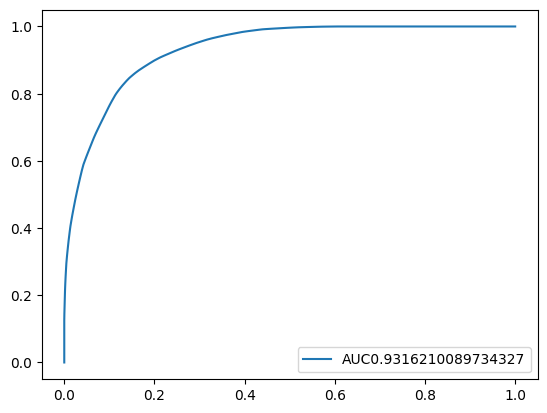

In [58]:
FPR, TPR, threshold=metrics.roc_curve(y_train1,pred_prob["prob_1"] )
auc=metrics.roc_auc_score(y_train1,pred_prob["prob_1"] )
plt.plot(FPR, TPR,label="AUC"+str(auc))
plt.legend()
plt.show()

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Imarticus/PGA44/Decision_tree")

In [ ]:
# Saving the model for future use
from joblib import dump
dump(dt4, "dt4.joblib")

['dt4.joblib']

In [ ]:
dump(selected_feat, "selected_feat.joblib")

['selected_feat.joblib']

In [ ]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'deposit'],
      dtype='object')